## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable.

In [25]:
import pandas as pd
import numpy as np

df = pd.read_csv("golub.csv")
df.head()

,Samples,BM.PB,Gender,Source,tissue.mf,cancer,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
0,39,BM,F,DFCI,BM:f,allB,-1363.276427,-1058.585495,-541.469194,74.349803,...,-35.081447,1565.618803,-485.680714,-170.261227,-919.114293,1675.050053,389.769289,-526.449219,-268.963924,-779.643092
1,40,BM,F,DFCI,BM:f,allB,-796.285053,-1167.103365,7.538493,83.544731,...,-404.737767,622.498054,-1275.354673,214.828233,-750.220666,-441.589276,9.841713,-671.911209,-671.911209,-644.272577
2,42,BM,F,DFCI,BM:f,allB,-679.139168,-1069.832308,-690.301829,-112.075981,...,193.780934,162.525483,-692.534361,517.498108,-674.674103,1265.396405,-65.192805,-714.859684,3672.066149,-822.021231
3,47,BM,M,DFCI,BM:m,allB,-1164.400197,-1109.939891,-990.127218,-238.574994,...,-256.002292,-31.625831,-621.975549,-458.594630,-630.689198,937.767618,-264.715941,-635.046022,475.944222,-794.070116
4,48,BM,F,DFCI,BM:f,allB,-1299.653758,-1401.998536,-1077.543813,-437.344560,...,-509.203660,383.591216,-905.517483,-36.675640,-1116.739685,316.087213,-210.879518,-953.423549,-291.448812,-1057.945876


In [26]:
df["cancer"].value_counts()

,count
cancer,
allB,38
aml,25
allT,9


In [27]:
df["target"] = df["cancer"].replace({
    "allB": 0,
    "allT": 0,
    "aml": 1
})

/tmp/ipykernel_6356/4101325661.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["target"] = df["cancer"].replace({


In [28]:
df["target"].value_counts()

,count
target,
0,47
1,25


2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes.

In [29]:
X = df.drop(columns=[
    "Samples", "BM.PB", "Gender", "Source",
    "tissue.mf", "cancer", "target"
])

y = df["target"]

In [30]:
print(X.shape)        # should be (72, ~7000)
y.value_counts()

(72, 7129)


,count
target,
0,47
1,25


In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

lm = LinearRegression()
lm.fit(X, y)

y_pred = lm.predict(X)
residuals = y - y_pred

mse_train = mean_squared_error(y, y_pred)
print("Training MSE:", mse_train)

Training MSE: 1.2522824482837894e-30


VERY small MSE. Overfitting.

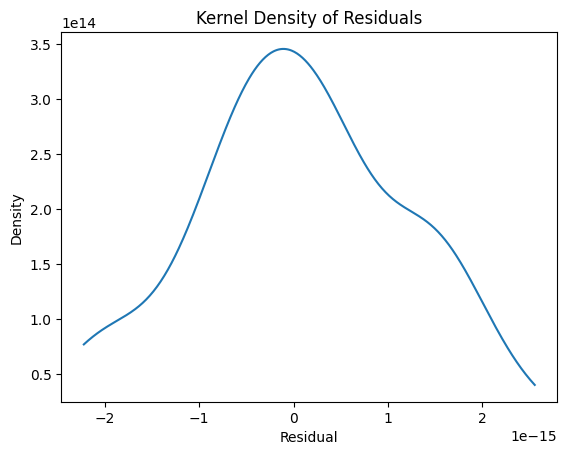

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

x_grid = np.linspace(residuals.min(), residuals.max(), 500)
kde = gaussian_kde(residuals)

plt.plot(x_grid, kde(x_grid))
plt.title("Kernel Density of Residuals")
plt.xlabel("Residual")
plt.ylabel("Density")
plt.show()

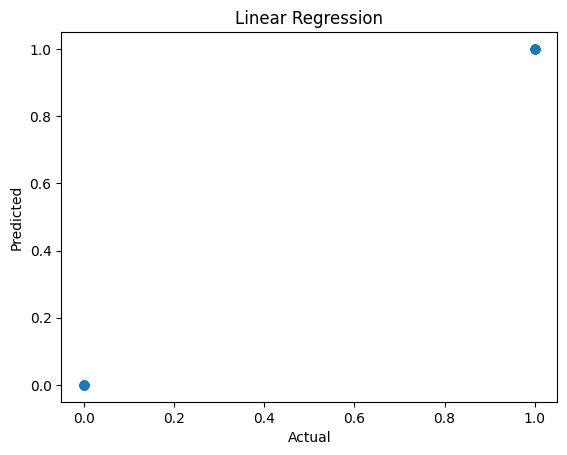

In [33]:
plt.scatter(y, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression")
plt.show()

The training MSE is extremely small (approximately 0), indicating that the model fits the training data almost perfectly. The kernel density plot of the residuals shows that they are tightly centered around zero, confirming this near-perfect fit. However, this suggests overfitting due to the large number of predictors relative to observations.

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

In [34]:
from sklearn.model_selection import KFold, cross_val_score

cv = KFold(n_splits=10, shuffle=True, random_state=1)

cv_mse = -cross_val_score(
    lm, X, y,
    cv=cv,
    scoring="neg_mean_squared_error"
)

print("Mean CV MSE:", cv_mse.mean())

Mean CV MSE: 0.049737064090641686


The training MSE is nearly zero, while the cross-validated MSE is significantly larger (approximately 0.05). This indicates that the model is overfitting the training data. Because the number of predictors is much larger than the number of observations, the model has very low bias but extremely high variance. As a result, it captures noise in the training data and performs worse on unseen data.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values.

In [35]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV

lasso_pipe = make_pipeline(
    StandardScaler(),
    LassoCV(cv=cv, random_state=1, max_iter=10000)
)

lasso_pipe.fit(X, y)

y_lasso = lasso_pipe.predict(X)

print("LASSO MSE:", mean_squared_error(y, y_lasso))

LASSO MSE: 0.0026877383222050546


In [36]:
lasso_model = lasso_pipe.named_steps["lassocv"]

coef = lasso_model.coef_

selected_genes = X.columns[coef != 0]
discarded = np.sum(coef == 0)

print("Selected genes:", len(selected_genes))
print("Discarded genes:", discarded)

Selected genes: 45
Discarded genes: 7084


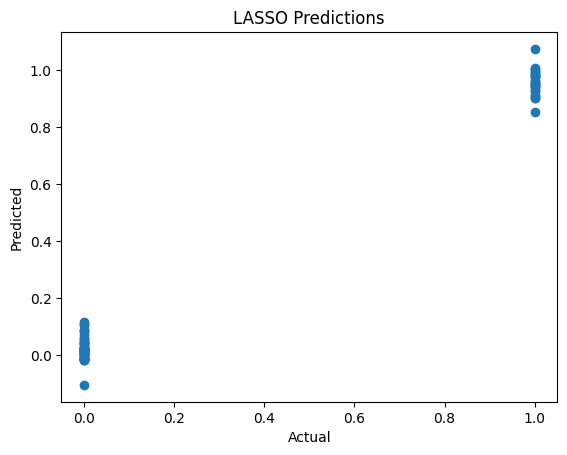

In [37]:
plt.scatter(y, y_lasso)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("LASSO Predictions")
plt.show()

The LASSO selects only 45 genes and discards over 7000, dramatically reducing model complexity. This indicates that only a small subset of genes is strongly predictive of leukemia type. By shrinking many coefficients to zero, LASSO reduces overfitting and improves interpretability compared to the full linear model.

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

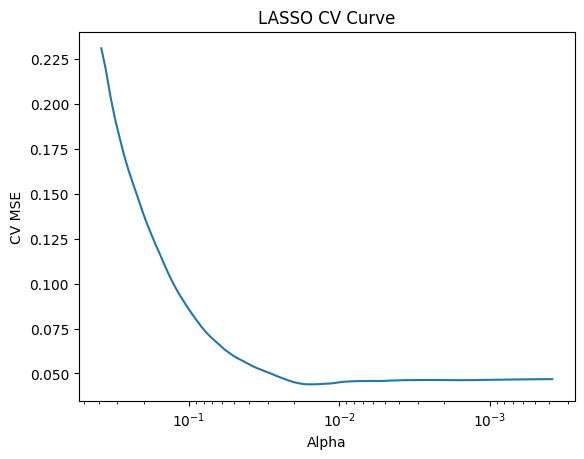

In [38]:
mean_mse = lasso_model.mse_path_.mean(axis=1)
alphas = lasso_model.alphas_

plt.plot(alphas, mean_mse)
plt.xscale("log")
plt.gca().invert_xaxis()
plt.xlabel("Alpha")
plt.ylabel("CV MSE")
plt.title("LASSO CV Curve")
plt.show()

The cross-validated MSE decreases as alpha decreases initially, indicating improved model fit. However, after a certain point, further decreasing alpha does not significantly improve performance and may lead to overfitting.
Large values of alpha result in underfitting because the penalty is too strong and most coefficients are shrunk toward zero. Very small values of alpha reduce the penalty, allowing the model to become more complex and potentially overfit.
The optimal alpha is the value that minimizes the cross-validated MSE, which occurs near the lowest point of the curve. From the plot, the optimal alpha appears to be around 10^(-2), where the MSE reaches its minimum.

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

Linear regression performs almost perfectly on the training data because it uses all predictors and is highly flexible, especially in a high-dimensional setting. However, this leads to overfitting and poor generalization. LASSO improves prediction by introducing regularization, shrinking coefficients, and reducing variance, which results in better performance on new data.

7. Why do regularization methods lend themselves to scenarios like precision health?

Regularization methods are well-suited for precision health because these datasets often contain thousands of features, such as gene expression levels, but relatively few samples. Regularization helps prevent overfitting, improves prediction accuracy, and identifies a smaller set of relevant biomarkers, making models more interpretable and clinically useful.

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

There are several risks in applying LASSO to precision health. First, the model may not generalize well to new patient populations if the training data are not representative. Second, LASSO may select different genes depending on the sample, leading to instability. Third, correlations between genes may cause the model to select variables that are not causally related to the disease. Finally, using such models in clinical decision-making could lead to harmful outcomes if predictions are incorrect or biased.